In [1]:
import sys; sys.path.append('..')
import inflation, numpy as np, importlib, fd_validation, visualization, parametric_pillows, wall_generation
from numpy.linalg import norm
import MeshFEM, parallelism, benchmark, utils

In [2]:
parallelism.set_max_num_tbb_threads(4)

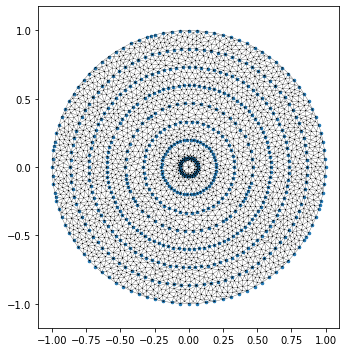

In [3]:
m, fuseMarkers, fuseEdges = wall_generation.triangulate_channel_walls(*parametric_pillows.concentricCircles(8, 50), 0.001)
visualization.plot_2d_mesh(m, pointList=np.where(np.array(fuseMarkers) == 1)[0], width=5, height=5)

In [4]:
isheet = inflation.InflatableSheet(m, np.array(fuseMarkers) != 0)

In [5]:
import py_newton_optimizer
opts = py_newton_optimizer.NewtonOptimizerOptions()
opts.useIdentityMetric = True
opts.beta = 1e-4
opts.gradTol = 1e-10

In [6]:
from tri_mesh_viewer import TriMeshViewer
viewer = TriMeshViewer(isheet, width=768, height=640)
viewer.showWireframe(True)
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [7]:
import time, vis
benchmark.reset()
isheet.setUseTensionFieldEnergy(True)
isheet.setUseHessianProjectedEnergy(False)
isheet.pressure = 20 * 3.75
opts.niter = 200
framerate = 5 # Update every 5 iterations
def cb(it):
    if it % framerate == 0:
        viewer.update()
cr = inflation.inflation_newton(isheet, isheet.rigidMotionPinVars, opts, callback=cb)
benchmark.report()

InflatableSheet setVars	0.000440121	1
Newton iterations	1.26415	1
    InflatableSheet energy	5.91278e-05	1
    Newton iterate	1.26365	112
        Backtracking	0.029249	111
            InflatableSheet energy	0.0114076	165
            InflatableSheet setVars	0.0170774	165
        Compute descent direction	1.0212	111
            newton_step	1.02101	111
                Newton solve	0.846302	158
                    CHOLMOD Numeric Factorize	0.727821	157
                    Solve	0.0996034	112
                        CHOLMOD Backsub	0.0700402	111
                        CHOLMOD Numeric Factorize	0.00258517	1
                        CHOLMOD Symbolic Factorize	0.0244379	1
                hessEval	0.153467	111
                largestMagnitudeEigenvalue	0.0192978	2
        Preamble	0.210224	112
            Callback	0.187296	112
            InflatableSheet energy	0.00763178	112
            InflatableSheet gradient	0.0129242	112
Full time	1.27301


In [8]:
viewer.update(scalarField=utils.getStrains(isheet)[:, 0])

### Repeat the inflation, this time recording it to a video
Requires `MeshFEM`'s `OffscreenRenderer` to be successfully built.

In [ ]:
isheet = inflation.InflatableSheet(m, np.array(fuseMarkers) != 0)

from tri_mesh_viewer import OffscreenTriMeshViewer
oview = OffscreenTriMeshViewer(isheet, width=768, height=640, wireframe=True)

benchmark.reset()
opts.niter=1000
oview.recordStart('cc_inflate.mp4')
isheet.pressure = 20 * 3.75
cr = inflation.inflation_newton(isheet, isheet.rigidMotionPinVars, opts,
                                callback=lambda it: oview.update())
benchmark.report()
oview.recordStop()

0.13820716746495976


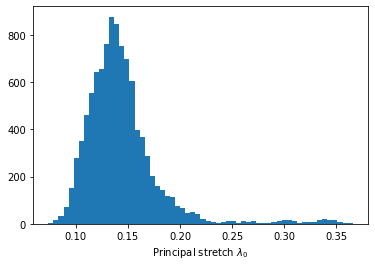

In [9]:
# Some basic statistics for the deformation
from matplotlib import pyplot as plt
strains = utils.getStrains(isheet)[:, 0]
plt.hist(strains, 60);
plt.xlabel('Principal stretch $\\lambda_0$')
print(np.median(strains))

### Analyze curvature of the inflated surface

In [10]:
isa = inflation.InflatedSurfaceAnalysis(isheet)
curvature = isa.curvature()
metric = isa.metric()

In [11]:
import matplotlib, vis
from tri_mesh_viewer import TriMeshViewer
isurf = isa.inflatedSurface()
metric_vf = vis.fields.VectorField(isurf, metric.sigma_2[:, None] * metric.left_stretch, vmin=0, vmax=1.0,
                                   align=vis.fields.VectorAlignment.CENTER, colormap=matplotlib.cm.viridis,
                                   glyph=vis.fields.VectorGlyph.CYLINDER)

viewer2 = TriMeshViewer(isurf, width=768, height=640, scalarField=vis.fields.ScalarField(isurf, curvature.meanCurvature(), colormap=matplotlib.cm.coolwarm), vectorField=metric_vf)
viewer2.showWireframe()
viewer2.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …